# QGSS Lecture 3

## Quantum gates and circuits

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer.library import save_statevector

qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.cx(0,1)
qc1.cx(1,0)
qc1.cx(0,1)

qc1.save_statevector()


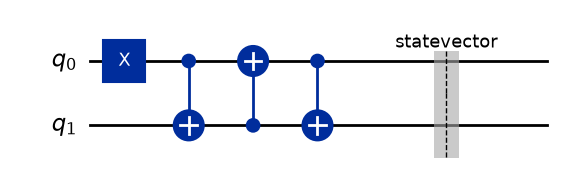

In [2]:
qc1.draw("mpl")

In [3]:
qc2 = QuantumCircuit(2)
qc2.x(0)
qc2.swap(0,1)

qc2.save_statevector()

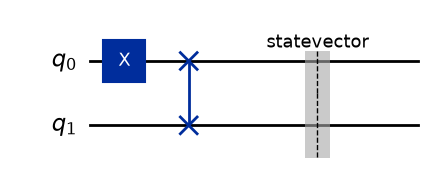

In [4]:
qc2.draw("mpl")

In [5]:
from qiskit_aer import AerSimulator
simulator = AerSimulator(method='statevector')

result_1 = simulator.run(qc1).result()
result_2 = simulator.run(qc2).result()

In [6]:
result_1.get_statevector() == result_2.get_statevector()

True

## Creating entanglement: Bell states

In [7]:
from qiskit.visualization import plot_histogram

qc_ent = QuantumCircuit(2)
qc_ent.h(0)
qc_ent.cx(0,1)

qc_ent.measure_active()

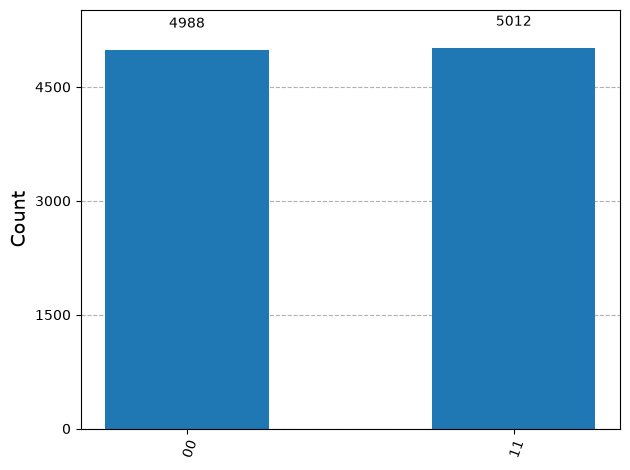

In [8]:
job = simulator.run(qc_ent, shots=10000)

result_ent = job.result()
counts = result_ent.get_counts()

plot_histogram(counts)

### Visualizing rotations on the Bloch Sphere

/var/folders/0q/zr1271ws7yg4gr657w15xlnh0000gn/T/ipykernel_41744/3912050044.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/0q/zr1271ws7yg4gr657w15xlnh0000gn/T/ipykernel_41744/3912050044.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


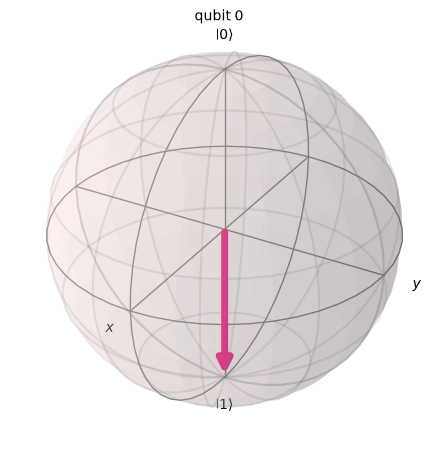

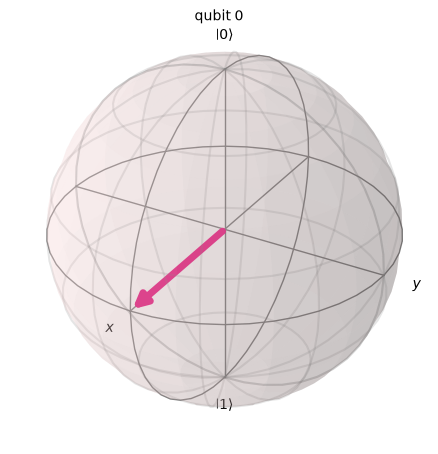

In [9]:
import numpy as np
from qiskit.visualization import plot_bloch_multivector
from matplotlib.pyplot import Figure
%matplotlib inline

qc_ref = QuantumCircuit(1)
qc_ref.h(0)
qc_ref.ry(np.pi/2,0)
qc_ref.save_statevector()
state = simulator.run(qc_ref).result().get_statevector()

qc_ref2 = QuantumCircuit(1)
qc_ref2.h(0)
qc_ref2.save_statevector()
state2 = simulator.run(qc_ref2).result().get_statevector()

fig1 = plot_bloch_multivector(state)
fig1.show()

fig2 = plot_bloch_multivector(state2)
fig2.show()

### Counting 2q gate depths

In [10]:
## Added to make it run properly --Dustin
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

In [11]:
from qiskit.transpiler import generate_preset_pass_manager
backend = service.least_busy(operational=True, simulator=False)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

qc = QuantumCircuit(20)
qc.h(range(20))

for i in range(19):
    qc.cx(i,i+1)
    # qc.cp(0.1, i, i+1)

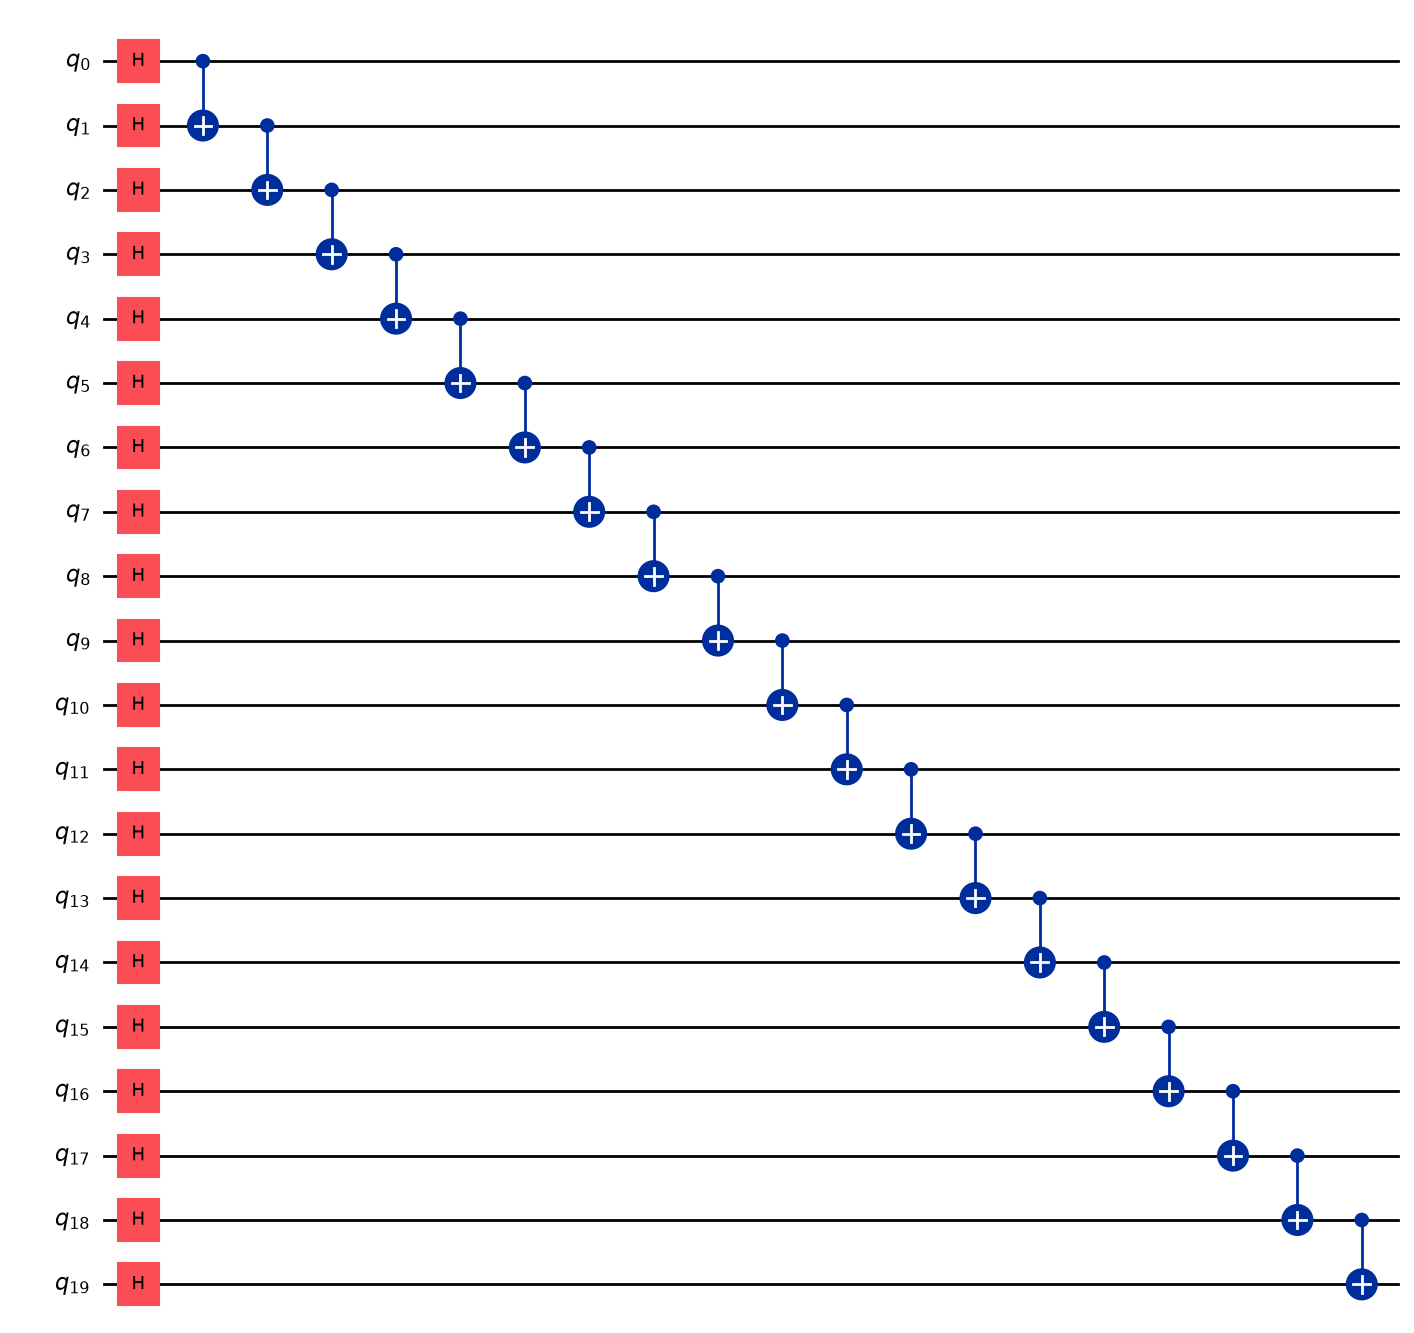

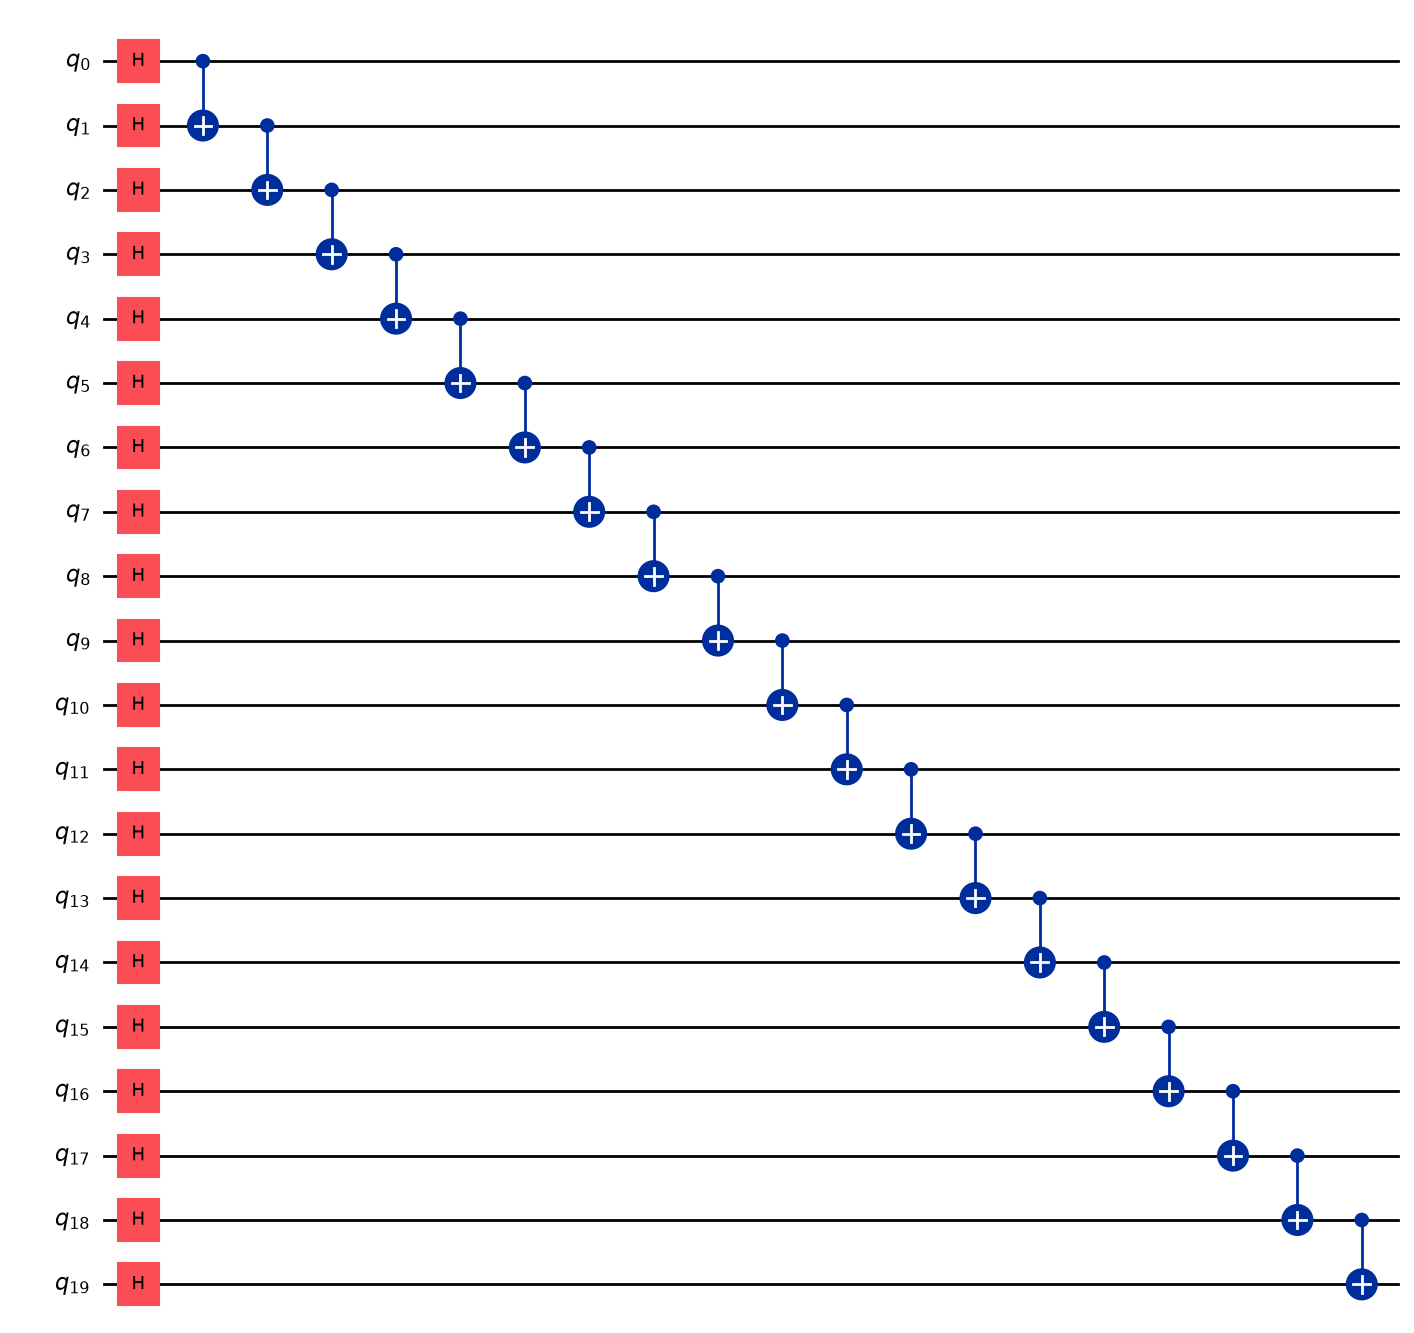

In [12]:
qc.draw("mpl", fold=-1)

In [13]:
xp_qc = pm.run(qc)

In [14]:
qc.num_nonlocal_gates()

19

In [15]:
xp_qc.num_nonlocal_gates()

19

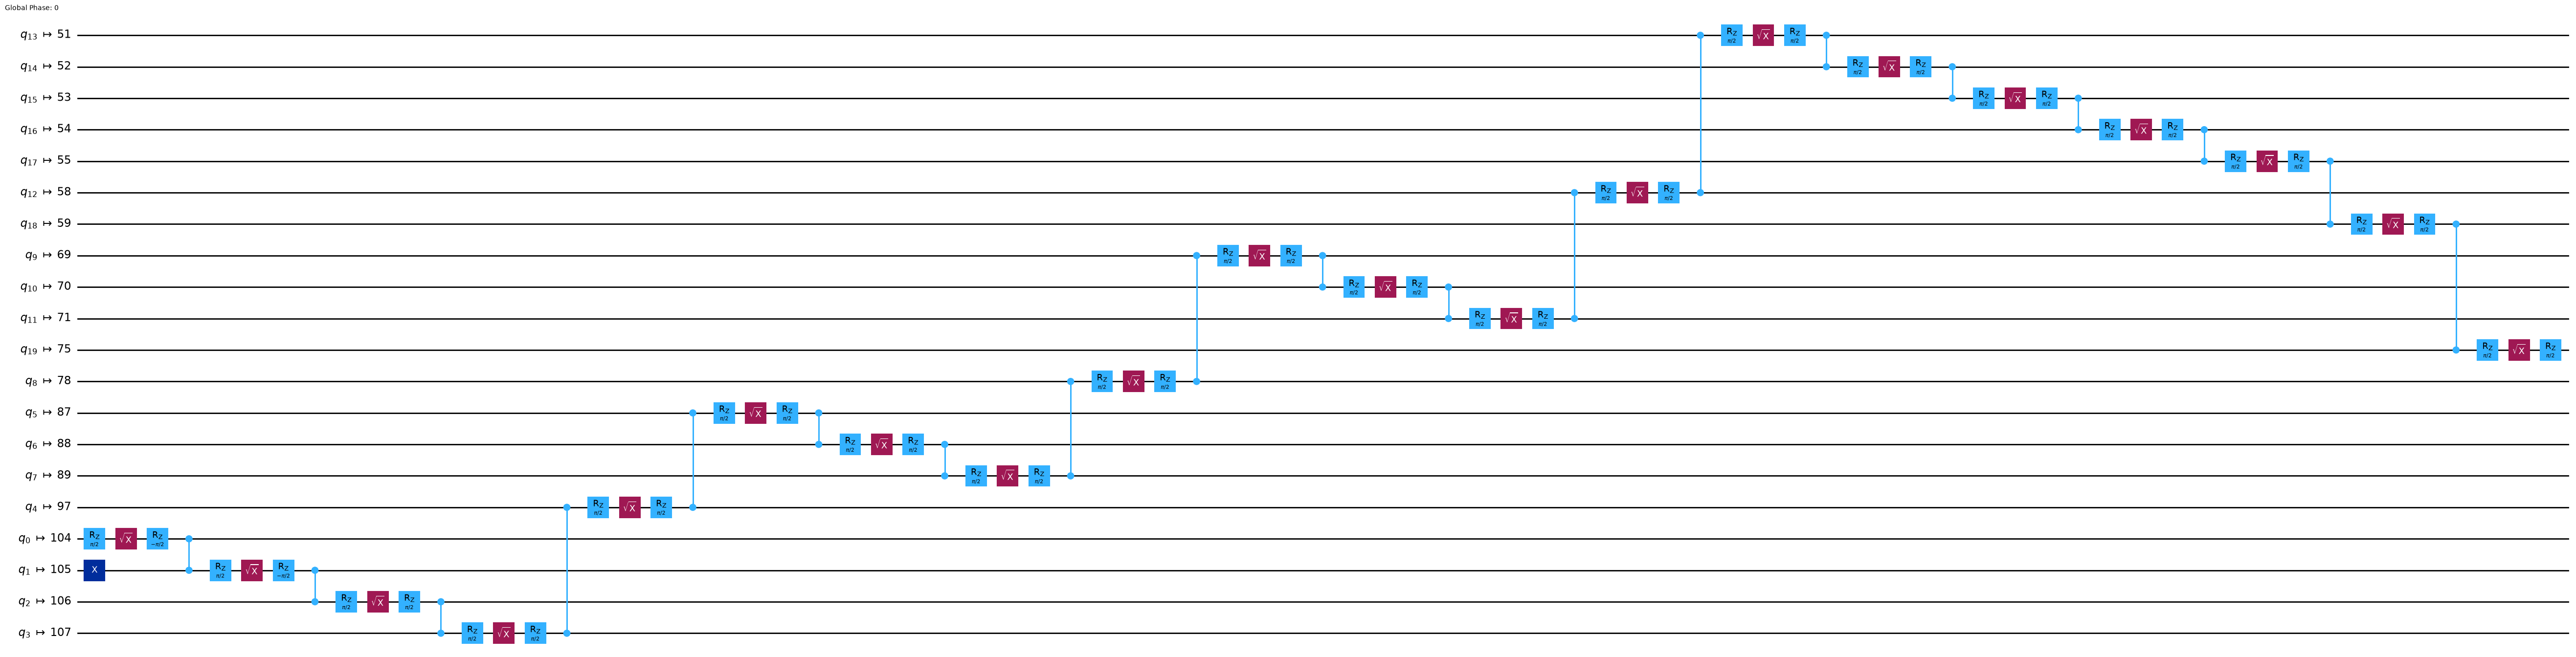

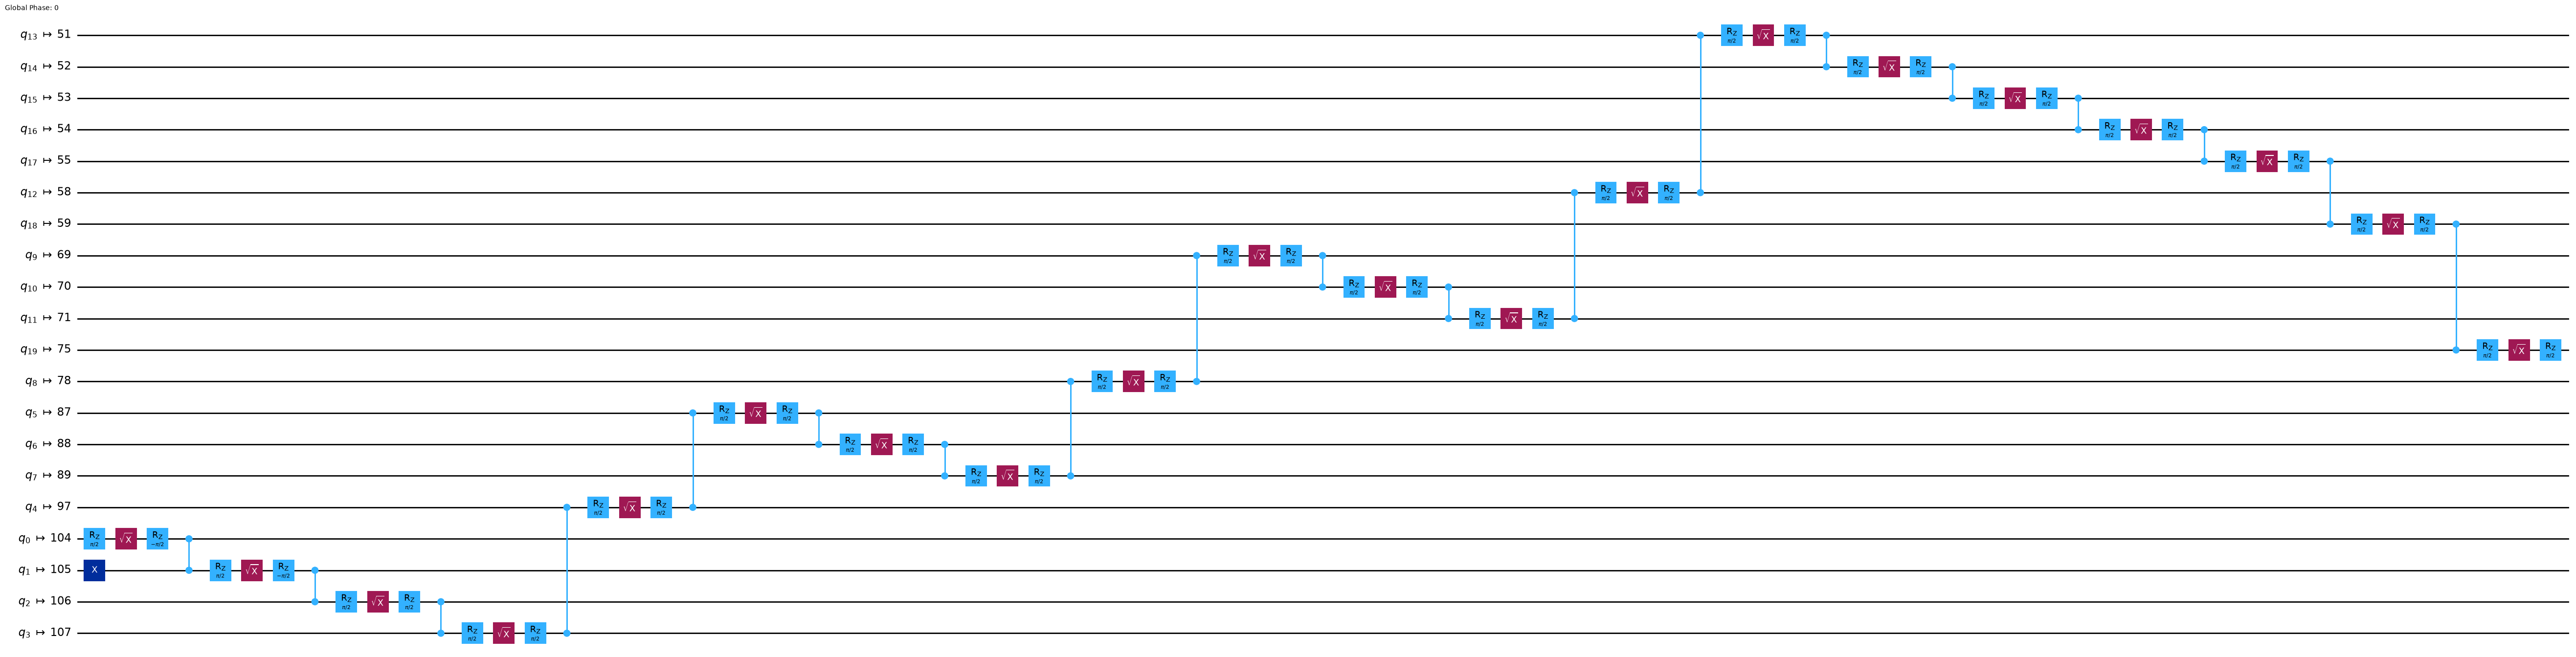

In [16]:
xp_qc.draw("mpl", fold=-1, idle_wires=False)

In [17]:
xp_qc.depth(lambda x:len(x.qubits)==2)

19

### Challenge: Can you build a circuit that produces a uniform superposition over 4 qubits